# EXPLORATORY DATA ANALYSIS (EDA) TO VERIFY DROPOUT AND ACADEMIC FAILURE RISKS
This notebook performs visualization and statistical analysis to validate early warning red flags.

In [1]:
# CELL 1: Library imports and visualization configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

In [ ]:
import os

# Install Kaggle API client
!pip install kaggle

# Create a directory for Kaggle configuration if it doesn't exist
# and ensure kaggle.json is placed there for authentication.
# If you run into Kaggle API authentication issues, please upload your kaggle.json
# to your Google Colab files section and move it to '/root/.kaggle/'
# or mount your Google Drive and copy it from there.
# For example:
# from google.colab import files
# files.upload() # Then move the uploaded kaggle.json
# !mkdir -p ~/.kaggle
# !mv kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# Dataset 1: Higher Education Predictors of Student Retention
dataset_1_id = "thedevastator/higher-education-predictors-of-student-retention"
dataset_1_name = "higher-education-predictors-of-student-retention.zip"
expected_file_1 = "higher_education.csv"

# Dataset 2: Student Performance Data Set
dataset_2_id = "larsen0966/student-performance-data-set"
dataset_2_name = "student-performance-data-set.zip"
expected_file_2_from_notebook = "student_performance.csv"

# Download and extract dataset 1
print(f"Downloading {dataset_1_id}...")
!kaggle datasets download -d {dataset_1_id} --quiet
print(f"Extracting {dataset_1_name}...")
!unzip -o {dataset_1_name} -d . > /dev/null
print(f"Extracted {expected_file_1}")

# Download and extract dataset 2
print(f"Downloading {dataset_2_id}...")
!kaggle datasets download -d {dataset_2_id} --quiet
print(f"Extracting {dataset_2_name}...")
!unzip -o {dataset_2_name} -d . > /dev/null
print(f"Extracted student-mat.csv and student-por.csv")

# The notebook expects 'student_performance.csv'. We will use student-por.csv and rename it.
# You can choose 'student-mat.csv' if preferred, or combine them if needed.
os.rename("student-por.csv", expected_file_2_from_notebook)
os.rename("dataset.csv", expected_file_1)

print("All datasets downloaded and extracted.")

In [12]:
!ls -la

total 672
drwxr-xr-x 1 root root   4096 Jun 13 00:48 .
drwxr-xr-x 1 root root   4096 Jun 13 00:22 ..
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config
-rw-r--r-- 1 root root 470858 Jan  3  2023 higher_education.csv
-rw-r--r-- 1 root root  89332 Jan  3  2023 higher-education-predictors-of-student-retention.zip
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root  93220 Mar 27  2020 student_performance.csv
-rw-r--r-- 1 root root  12353 Mar 27  2020 student-performance-data-set.zip


In [13]:
# CELL 2: Load datasets
try:
    df_univ = pd.read_csv("higher_education.csv")
    df_school = pd.read_csv("student_performance.csv")
    print("Data loaded successfully.")
    print(f"Higher Education dataset: {df_univ.shape[0]} rows, {df_univ.shape[1]} columns")
    print(f"Student Performance dataset: {df_school.shape[0]} rows, {df_school.shape[1]} columns")
except FileNotFoundError as e:
    print(f"Error: File not found. Please verify your file paths. Details: {e}")

Data loaded successfully.
Higher Education dataset: 4424 rows, 35 columns
Student Performance dataset: 649 rows, 33 columns


---
## PART 1: HIGHER EDUCATION DATASET (Predictors of Student Retention)
Objective: Verify academic, financial, and demographic indicators for the 'Target = Dropout' group.

/tmp/ipykernel_3163/402650822.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_univ_filtered, x='Target', y='Curricular units 1st sem (grade)', ax=axes[1], palette="Set2")


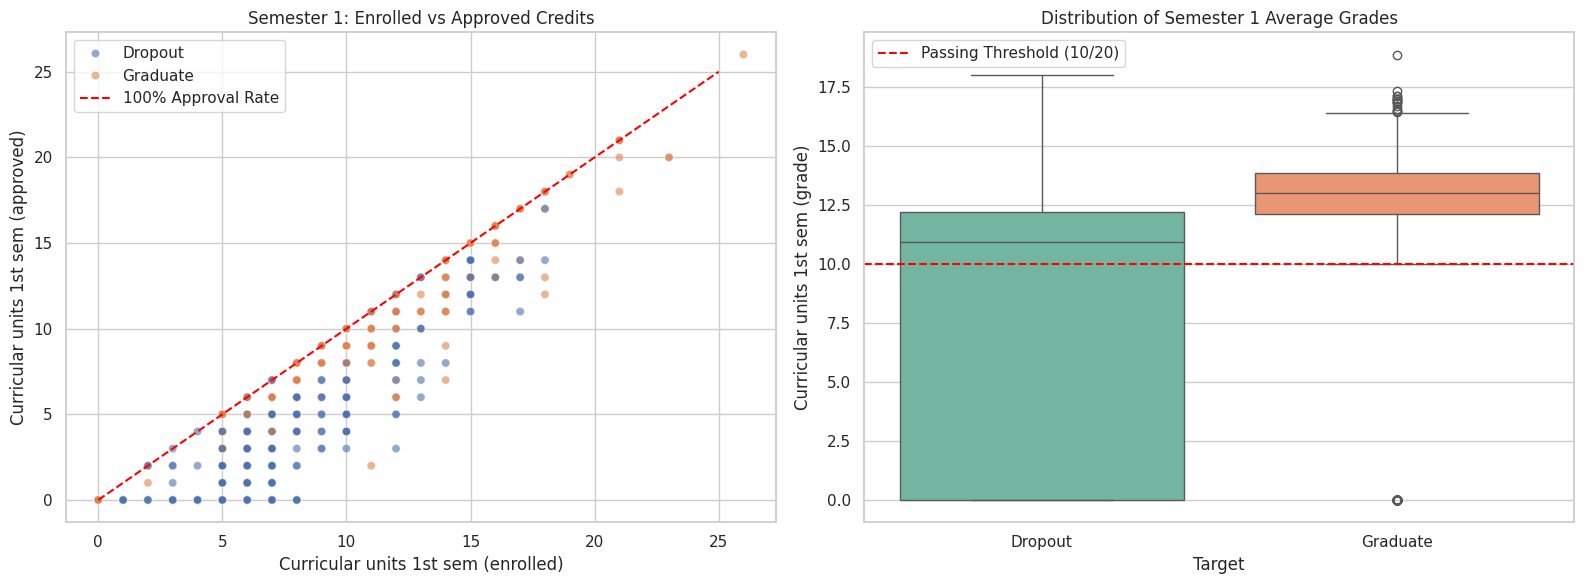

Probability of a student with Sem 1 grade < 10 dropping out: 88.12%


In [14]:
# CELL 3: 1.1 Verify Academic Performance Decline (Credit Deficit)
# Filter out 'Enrolled' status to focus on 'Dropout' vs 'Graduate'
df_univ_filtered = df_univ[df_univ['Target'].isin(['Dropout', 'Graduate'])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Enrolled vs Approved Credits in 1st Semester
sns.scatterplot(data=df_univ_filtered, x='Curricular units 1st sem (enrolled)',
                y='Curricular units 1st sem (approved)', hue='Target', alpha=0.6, ax=axes[0])
axes[0].set_title("Semester 1: Enrolled vs Approved Credits")
axes[0].plot([0, 25], [0, 25], color='red', linestyle='--', label='100% Approval Rate')
axes[0].legend()

# Box plot: 1st Semester Grade Distribution
sns.boxplot(data=df_univ_filtered, x='Target', y='Curricular units 1st sem (grade)', ax=axes[1], palette="Set2")
axes[1].axhline(y=10, color='red', linestyle='--', label='Passing Threshold (10/20)')
axes[1].set_title("Distribution of Semester 1 Average Grades")
axes[1].legend()

plt.tight_layout()
plt.show()

# Calculate statistical probability
dropout_low_grade = df_univ_filtered[(df_univ_filtered['Curricular units 1st sem (grade)'] < 10) & (df_univ_filtered['Target'] == 'Dropout')].shape[0]
total_low_grade = df_univ_filtered[df_univ_filtered['Curricular units 1st sem (grade)'] < 10].shape[0]
print(f"Probability of a student with Sem 1 grade < 10 dropping out: {(dropout_low_grade/total_low_grade)*100:.2f}%")

/tmp/ipykernel_3163/1256429711.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Debt', 'Has Debt'])
/tmp/ipykernel_3163/1256429711.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Scholarship', 'Has Scholarship'])


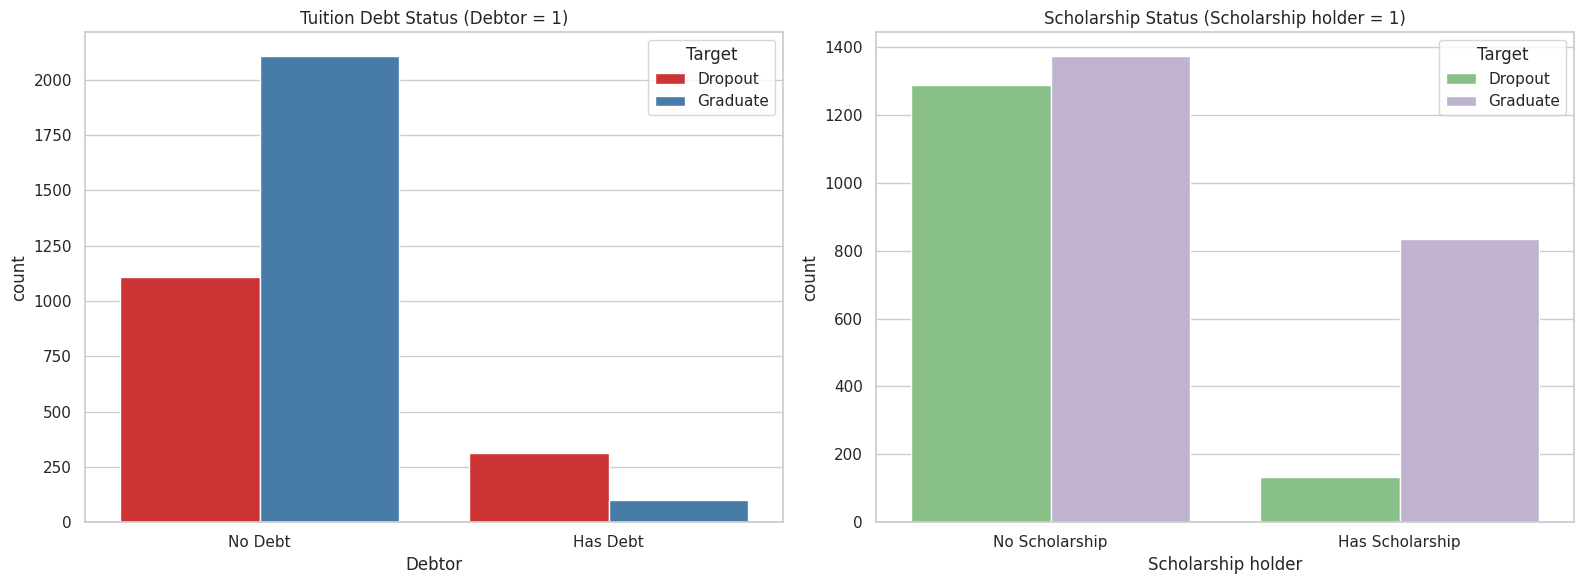

In [15]:
# CELL 4: 1.2 Verify Financial Hardships (Tuition Debt and Scholarships)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Countplot: Tuition Debt Status
sns.countplot(data=df_univ_filtered, x='Debtor', hue='Target', ax=axes[0], palette="Set1")
axes[0].set_title("Tuition Debt Status (Debtor = 1)")
axes[0].set_xticklabels(['No Debt', 'Has Debt'])

# Countplot: Scholarship Status
sns.countplot(data=df_univ_filtered, x='Scholarship holder', hue='Target', ax=axes[1], palette="Accent")
axes[1].set_title("Scholarship Status (Scholarship holder = 1)")
axes[1].set_xticklabels(['No Scholarship', 'Has Scholarship'])

plt.tight_layout()
plt.show()

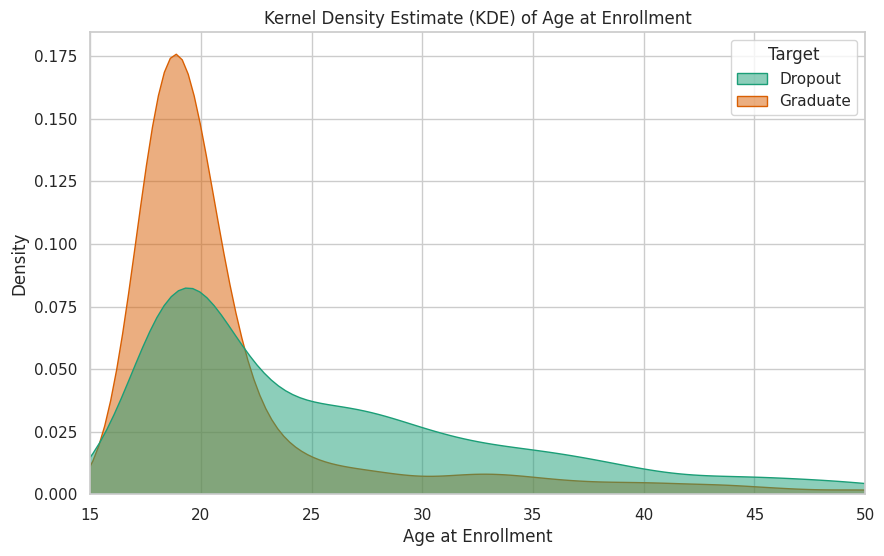

In [16]:
# CELL 5: 1.3 Verify Demographics (Age at Enrollment)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_univ_filtered, x='Age at enrollment', hue='Target', fill=True, common_norm=False, palette="Dark2", alpha=0.5)
plt.title("Kernel Density Estimate (KDE) of Age at Enrollment")
plt.xlabel("Age at Enrollment")
plt.ylabel("Density")
plt.xlim(15, 50)
plt.show()

---
## PHẦN 2: TẬP DỮ LIỆU TRUNG HỌC (Student Performance Data Set)
Objective: Verify lifestyle and historical failure factors affecting final G3 grades.

/tmp/ipykernel_3163/351553149.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_school, x='failures', y='G3', ax=axes[0], palette="vlag")


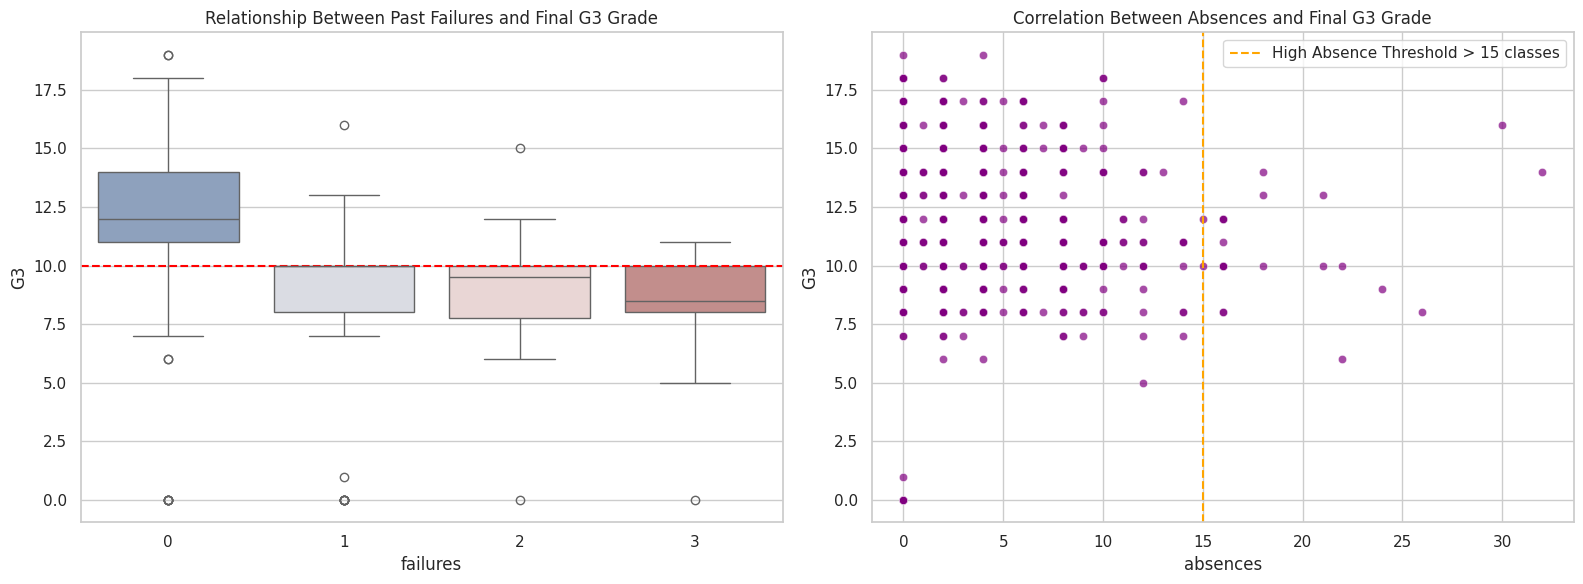

Average absences for G3 = 0 group (Dropout/Failure): 0.00 classes
Average absences for Passing group (G3 >= 10): 3.49 classes


In [17]:
# CELL 6: 2.1 Cumulative Failure and Absences Effect
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: Past failures vs Final G3 grade
sns.boxplot(data=df_school, x='failures', y='G3', ax=axes[0], palette="vlag")
axes[0].set_title("Relationship Between Past Failures and Final G3 Grade")
axes[0].axhline(y=10, color='red', linestyle='--')

# Scatter plot: Absences vs Final G3 grade
sns.scatterplot(data=df_school, x='absences', y='G3', alpha=0.7, color='purple', ax=axes[1])
axes[1].axvline(x=15, color='orange', linestyle='--', label='High Absence Threshold > 15 classes')
axes[1].set_title("Correlation Between Absences and Final G3 Grade")
axes[1].legend()

plt.tight_layout()
plt.show()

# Calculate mean statistics
mean_absences_g3_0 = df_school[df_school['G3'] == 0]['absences'].mean()
mean_absences_g3_high = df_school[df_school['G3'] >= 10]['absences'].mean()
print(f"Average absences for G3 = 0 group (Dropout/Failure): {mean_absences_g3_0:.2f} classes")
print(f"Average absences for Passing group (G3 >= 10): {mean_absences_g3_high:.2f} classes")

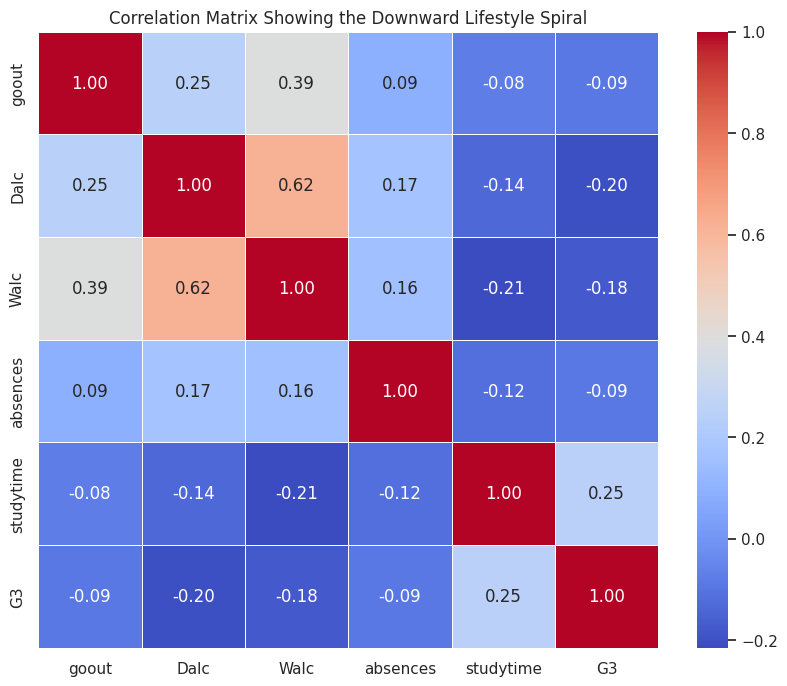

Average G3 grade by weekend alcohol consumption (Walc from 1 - low to 5 - high):
Walc
1    12.360324
2    12.260000
3    11.666667
4    11.034483
5    10.555556


In [18]:
# CELL 7: 2.2 Lifestyle Degradation Patterns
# Correlation matrix to display structural behavior traits
lifestyle_cols = ['goout', 'Dalc', 'Walc', 'absences', 'studytime', 'G3']
corr_matrix = df_school[lifestyle_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix Showing the Downward Lifestyle Spiral")
plt.show()

# Breakdown of G3 score by weekend alcohol consumption level
print("Average G3 grade by weekend alcohol consumption (Walc from 1 - low to 5 - high):")
print(df_school.groupby('Walc')['G3'].mean().to_string())

/tmp/ipykernel_3163/438724095.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_school, x='higher', y='G3', ax=axes[0], order=['no', 'yes'], palette="Set2")
/tmp/ipykernel_3163/438724095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_school, x='Medu', y='G3', ax=axes[1], palette="Blues")
/tmp/ipykernel_3163/438724095.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Education', 'Primary School', 'Middle School', 'High School', 'Higher Education'])


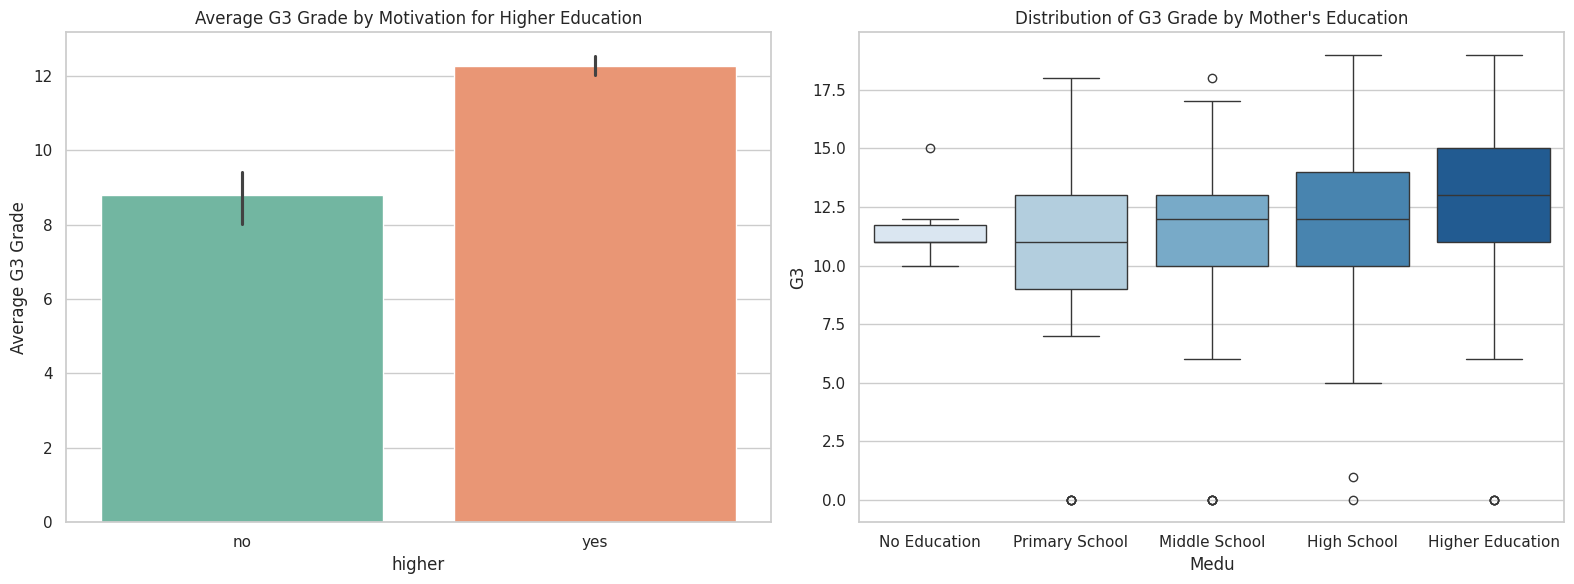

In [19]:
# CELL 8: 2.3 Lack of Long-term Goals and Family Support Structure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot: Motivation for higher education vs G3
sns.barplot(data=df_school, x='higher', y='G3', ax=axes[0], order=['no', 'yes'], palette="Set2")
axes[0].set_title("Average G3 Grade by Motivation for Higher Education")
axes[0].set_ylabel("Average G3 Grade")

# Box plot: Mother's educational level vs G3
sns.boxplot(data=df_school, x='Medu', y='G3', ax=axes[1], palette="Blues")
axes[1].set_title("Distribution of G3 Grade by Mother's Education")
axes[1].set_xticklabels(['No Education', 'Primary School', 'Middle School', 'High School', 'Higher Education'])

plt.tight_layout()
plt.show()